# Outlier Filtering for Cool Dwarf Color-logg Relationships

This notebook implements outlier detection and filtering for the cross-matched Gaia-LAMOST-LAMOST_vac dataset.

**Approach Summary:**
- Use absolute magnitude colors (intrinsic stellar properties)
- 0.1 dex logg bins from 3.5-5.8
- **Iterative sigma clipping (astropy) per bin with median centrality**
- **Remove stars flagged in ≥1 colors (strict quality control)**


In [2]:
import pandas as pd

In [3]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.stats import sigma_clip
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define paths using Path for cross-platform compatibility
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_result')
NOTEBOOKS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\notebooks')
RESULTS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(exist_ok=True)

## Phase 1: Load and Inspect Dataset

Load the cross-matched dataset and verify its structure.

In [4]:
# Load the cross-matched dataset
input_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_K_dwarf.csv'
df = pd.read_csv(input_path)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")

# Pre-processing: Standardize to one set of Gaia magnitudes to avoid recomputing colors
print(f"Initial columns: {len(df.columns)}")
# Drop apparent Gaia magnitudes as absolute ones are available and preferred for intrinsic properties
df.drop(columns=['Gmag', 'BPmag', 'RPmag'], inplace=True, errors='ignore')
print(f"Columns after dropping apparent Gaia mags: {len(df.columns)}")

# Convert Pan-STARRS apparent magnitudes to absolute magnitudes
# Formula: M = m - 5 * log10(d) + 5
ps_mags = ['mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y']
for mag in ps_mags:
    if mag in df.columns and 'distance_gaia_pc' in df.columns:
        abs_mag_name = mag.replace('mag_ps_', 'A_ps_')
        df[abs_mag_name] = df[mag] - 5 * np.log10(df['distance_gaia_pc']) + 5
        df.drop(columns=[mag], inplace=True)
        print(f"Converted {mag} to {abs_mag_name}")

print("\nColumns:", df.columns.tolist())
print(f"\nlogg range: {df['logg'].min():.2f} - {df['logg'].max():.2f}")
print(f"logg mean: {df['logg'].mean():.2f}, median: {df['logg'].median():.2f}")


Dataset loaded: 266250 rows, 28 columns
Initial columns: 28
Columns after dropping apparent Gaia mags: 25
Converted mag_ps_g to A_ps_g
Converted mag_ps_r to A_ps_r
Converted mag_ps_i to A_ps_i
Converted mag_ps_z to A_ps_z
Converted mag_ps_y to A_ps_y

Columns: ['obsid', 'subclass', 'gaia_source_id', 'distance_gaia_pc', 'teff', 'logg', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_BAP', 'A_VAP', 'A_RAP', 'A_GSD', 'A_RSD', 'A_ISD', 'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y']

logg range: 0.27 - 4.90
logg mean: 4.47, median: 4.63


In [5]:
df.head()

,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,A_VAP,A_RAP,A_GSD,A_RSD,A_ISD,A_ps_g,A_ps_r,A_ps_i,A_ps_z,A_ps_y
0,300702165,K4,38655544960,318.555530,4728.65,4.741,6.509792,6.775236,5.527842,4.860249,...,7.045762,6.070487,7.369662,6.602582,6.150263,7.376574,6.589774,6.276174,6.146475,6.041074
1,215211,K3,90984587296512,884.605365,4864.24,4.693,6.035300,6.921498,6.440915,4.652506,...,6.313395,4.810423,6.731211,6.209431,5.678612,6.972152,6.218852,5.926052,5.802552,5.694352
2,215166,K3,281681135151744,898.045414,4875.46,4.818,6.283644,7.221240,5.946499,5.173040,...,6.533691,6.077611,6.024661,6.325306,6.808714,7.443109,6.751909,6.460109,6.339008,6.241208
3,482908140,K5,339959547115904,425.653738,4230.82,4.498,5.091015,7.537307,6.330301,4.688434,...,6.153604,5.990835,8.376172,6.410096,5.302228,8.093318,7.022418,6.578218,6.383418,6.267118
4,757516059,K1,611951236036096,519.612255,5233.11,4.516,4.780574,6.194766,4.270197,3.816624,...,5.491312,4.918054,5.608222,4.809196,4.976801,6.231103,5.602003,5.384704,5.313703,5.237703


In [6]:
# Basic data quality check
print("Missing values summary:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

# Filter to reasonable logg range for dwarfs
logg_min, logg_max = 3.5, 5.8
df = df[(df['logg'] >= logg_min) & (df['logg'] <= logg_max)]
print(f"\nAfter logg range filtering: {len(df)} stars")


Missing values summary:
Series([], dtype: int64)

After logg range filtering: 249253 stars


## Phase 2: Create Color Indices

Create color indices from all 21 distinct magnitudes for physics-based intrinsic properties.

In [7]:
# Define ALL 19 distinct magnitudes sorted by center wavelength (shortest to longest)
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP', 
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H', 
    'A_KS', 'A_W1', 'A_W2'
]

"""
all_magnitudes = [
    # Gaia absolute magnitudes
    'A_GG', 'A_BP', 'A_RP',
    # Pan-STARRS
    'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y',
    # 2MASS
    'A_J', 'A_H', 'A_KS',
    # WISE
    'A_W1', 'A_W2',
    # APASS
    'A_BAP', 'A_VAP', 'A_RAP',
    # SDSS
    'A_GSD', 'A_RSD', 'A_ISD'
]
"""

# Check which magnitudes are actually in the dataframe
available_mags = [m for m in sorted_mags if m in df.columns]
missing_mags = [m for m in sorted_mags if m not in df.columns]

print(f"Expected magnitudes: {len(sorted_mags)}")
print(f"Available magnitudes: {len(available_mags)}")
if missing_mags:
    print(f"Missing magnitudes: {missing_mags}")
else:
    print("All expected magnitudes are present!")

# Generate all 171 color combinations (shorter wavelength - longer wavelength)
color_combinations = {}
for i in range(len(sorted_mags)):
    for j in range(i + 1, len(sorted_mags)):
        mag1 = sorted_mags[i]
        mag2 = sorted_mags[j]
        if mag1 in available_mags and mag2 in available_mags:
            color_name = f'COLOR_{mag1}_{mag2}'
            color_combinations[color_name] = (mag1, mag2)

print(f"Generated {len(color_combinations)} color combinations.")

# Calculate colors
for color_name, (mag1, mag2) in color_combinations.items():
    df[color_name] = df[mag1] - df[mag2]

# Drop rows with NaN in any of the calculated colors
initial_len = len(df)
df.dropna(subset=list(color_combinations.keys()), inplace=True)
print(f"Dropped {initial_len - len(df)} rows with NaN colors. Remaining: {len(df)}")

Expected magnitudes: 19
Available magnitudes: 19
All expected magnitudes are present!
Generated 171 color combinations.
Dropped 0 rows with NaN colors. Remaining: 249253


## Phase 3: logg Binning

Define logg bins with fixed width (0.1 dex) ensuring adequate samples per bin.


logg bin statistics:
           logg                
          count  min  max  mean
logg_bin                       
3.5-3.6    2174  3.5  3.6  3.55
3.6-3.7    2397  3.6  3.7  3.65
3.7-3.8    2857  3.7  3.8  3.75
3.8-3.9    2378  3.8  3.9  3.85
3.9-4.0    1128  3.9  4.0  3.95
4.0-4.1     810  4.0  4.1  4.05
4.1-4.2    1366  4.1  4.2  4.16
4.2-4.3    2748  4.2  4.3  4.26
4.3-4.4    5999  4.3  4.4  4.36
4.4-4.5   17415  4.4  4.5  4.46
4.5-4.6   54029  4.5  4.6  4.56
4.6-4.7   94735  4.6  4.7  4.65
4.7-4.8   52601  4.7  4.8  4.74
4.8-4.9    8616  4.8  4.9  4.83
4.9-5.0       0  NaN  NaN   NaN
5.0-5.1       0  NaN  NaN   NaN
5.1-5.2       0  NaN  NaN   NaN
5.2-5.3       0  NaN  NaN   NaN
5.3-5.4       0  NaN  NaN   NaN
5.4-5.5       0  NaN  NaN   NaN
5.5-5.6       0  NaN  NaN   NaN
5.6-5.7       0  NaN  NaN   NaN
5.7-5.8       0  NaN  NaN   NaN


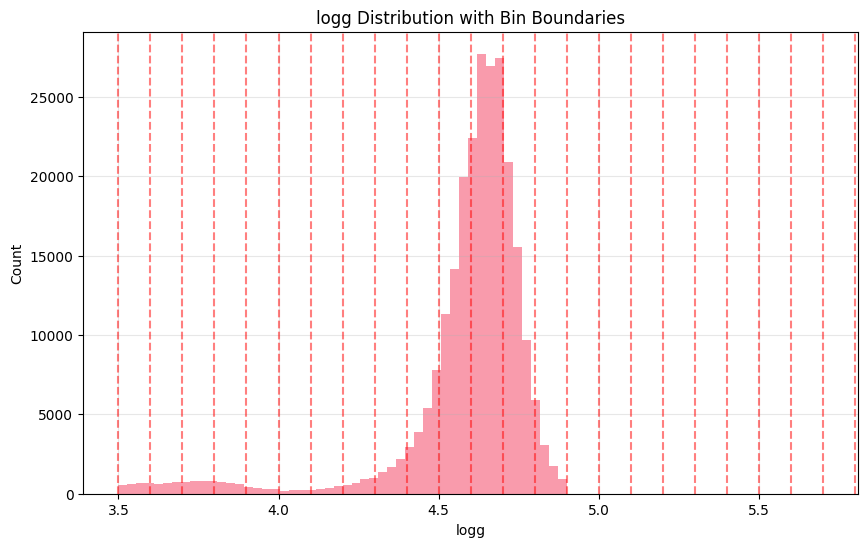

In [8]:
# Create logg bins
bin_width = 0.1  # dex
logg_bins = np.arange(3.5, 5.8 + bin_width, bin_width)

# Add bin column to dataframe
df['logg_bin'] = pd.cut(df['logg'], logg_bins, right=False,
                        labels=[f'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}'
                               for i in range(len(logg_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('logg_bin').agg({
    'logg': ['count', 'min', 'max', 'mean']
}).round(2)

print("logg bin statistics:")
print(bin_stats)

# Visualize logg distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['logg'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for logg_boundary in logg_bins:
    ax.axvline(logg_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('logg')
ax.set_ylabel('Count')
ax.set_title('logg Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
plt.show()


In [9]:
"""# Create logg bins
bin_width = 0.1  # dex
logg_bins = np.arange(3.5, 5.8 + bin_width, bin_width)

# Add bin column to dataframe
df['logg_bin'] = pd.cut(df['logg'], logg_bins, right=False, 
                        labels=[f'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}' 
                               for i in range(len(logg_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('logg_bin').agg({
    'logg': ['count', 'min', 'max', 'mean']
}).round(2)

print("logg bin statistics:")
print(bin_stats)

# Visualize logg distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['logg'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for logg_boundary in logg_bins:
    ax.axvline(logg_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('logg')
ax.set_ylabel('Count')
ax.set_title('logg Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
#plt.savefig(RESULTS_DIR / 'logg_distribution_bins.png', dpi=150, bbox_inches='tight')
plt.show()"""

'# Create logg bins\nbin_width = 0.1  # dex\nlogg_bins = np.arange(3.5, 5.8 + bin_width, bin_width)\n\n# Add bin column to dataframe\ndf[\'logg_bin\'] = pd.cut(df[\'logg\'], logg_bins, right=False, \n                        labels=[f\'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}\' \n                               for i in range(len(logg_bins)-1)])\n\n# Check bin statistics\nbin_stats = df.groupby(\'logg_bin\').agg({\n    \'logg\': [\'count\', \'min\', \'max\', \'mean\']\n}).round(2)\n\nprint("logg bin statistics:")\nprint(bin_stats)\n\n# Visualize logg distribution\nfig, ax = plt.subplots(1, 1, figsize=(10, 6))\ndf[\'logg\'].plot.hist(bins=50, ax=ax, alpha=0.7)\n\n# Add vertical lines for bin boundaries\nfor logg_boundary in logg_bins:\n    ax.axvline(logg_boundary, color=\'red\', linestyle=\'--\', alpha=0.5)\n\nax.set_xlabel(\'logg\')\nax.set_ylabel(\'Count\')\nax.set_title(\'logg Distribution with Bin Boundaries\')\nax.grid(True, alpha=0.3)\n#plt.savefig(RESULTS_DIR / \'logg_distribution_

## Phase 4: Outlier Detection (Iterative Sigma Clipping)

Apply iterative sigma clipping using `astropy.stats.sigma_clip` per logg bin for each color index.


In [10]:
def detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None):
    """
    Use astropy's iterative sigma clipping to detect outliers.
    Returns a boolean series where True indicates an outlier.
    """
    values = df_bin[color_name].dropna()
    if len(values) < 10:
        return pd.Series(False, index=df_bin.index)
    
    # Apply sigma clipping
    clipped_data = sigma_clip(values, sigma=sigma, maxiters=maxiters, cenfunc='median', stdfunc='std')
    
    # Identify outliers (values that were clipped/masked)
    # clipped_data is a masked array where masked=True means outlier
    outlier_mask = clipped_data.mask
    
    return pd.Series(outlier_mask, index=values.index)

# Create outlier flags for each color and bin
outlier_columns = []

for color_name in color_combinations.keys():
    outlier_col_name = f'{color_name}_outlier'
    outlier_columns.append(outlier_col_name)
    df[outlier_col_name] = False 
    
    for bin_name, df_bin in df.groupby('logg_bin'):
        outlier_mask = detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None)
        df.loc[outlier_mask.index, outlier_col_name] = outlier_mask

print(f"Created {len(outlier_columns)} outlier flag columns using iterative sigma clipping")


Created 171 outlier flag columns using iterative sigma clipping


In [11]:
# Convergence Diagnostics and Detailed Statistics
print("=" * 80)
print("=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===")
print("=" * 80)

convergence_stats = {}

for color_name in color_combinations.keys():
    convergence_stats[color_name] = {}
    
    for bin_name, df_bin in df.groupby('logg_bin'):
        values = df_bin[color_name].dropna()
        if len(values) >= 10:
            # Run sigma clipping with 5 iterations
            clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, 
                                   cenfunc='median', stdfunc='std')
            # Run sigma clipping until convergence (maxiters=None)
            clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, 
                                       cenfunc='median', stdfunc='std')
            
            convergence_stats[color_name][bin_name] = {
                'original_N': len(values),
                'after_5_iters_N': int((~clipped_5.mask).sum()),
                'final_N': int((~clipped_final.mask).sum()),
                'removed_5_iters': int(clipped_5.mask.sum()),
                'removed_final': int(clipped_final.mask.sum()),
                'original_median': float(np.median(values)),
                'original_std': float(np.std(values)),
                'final_median': float(np.median(values[~clipped_final.mask])),
                'final_std': float(np.std(values[~clipped_final.mask]))
            }

# Print detailed convergence statistics per color
print("\n=== Per-Color Convergence Summary ===\n")
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    
    print(f"\n{color_name}:")
    print(f"  Total stars: {total_original}")
    print(f"  Removed after 5 iters: {total_removed_5} ({100*total_removed_5/total_original:.3f}%)")
    print(f"  Removed (converged):   {total_removed_final} ({100*total_removed_final/total_original:.3f}%)")
    print(f"  Difference (5 vs converged): {total_removed_final - total_removed_5}")
    
    print(f"  Per-bin breakdown:")
    for bin_name, stats in convergence_stats[color_name].items():
        print(f"    {bin_name}: {stats['original_N']:5d} -> {stats['final_N']:5d} "
              f"(removed: {stats['removed_final']:4d}, "
              f"median: {stats['original_median']:.3f} -> {stats['final_median']:.3f}, "
              f"std: {stats['original_std']:.3f} -> {stats['final_std']:.3f})")

# Create strict consensus outlier flag: outlier if flagged in ANY color (>=1)
df['outlier_consensus'] = df[outlier_columns].any(axis=1)

total_stars = len(df)
outlier_stars = df['outlier_consensus'].sum()
clean_stars = total_stars - outlier_stars

print("\n" + "=" * 80)
print("=== FINAL OUTLIER SUMMARY ===")
print("=" * 80)
print(f"\nTotal stars: {total_stars}")
print(f"Outliers (flagged in ≥1 colors): {outlier_stars} ({100*outlier_stars/total_stars:.2f}%)")
print(f"Clean stars: {clean_stars} ({100*clean_stars/total_stars:.2f}%)")

print("\nSurvival statistics by logg bin:")
bin_survival = df.groupby('logg_bin').agg({
    'obsid': 'count',
    'outlier_consensus': 'sum'
})
bin_survival.columns = ['total', 'outliers']
bin_survival['survival_rate'] = 100 * (1 - bin_survival['outliers']/bin_survival['total'])
print(bin_survival.round(2))


=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===

=== Per-Color Convergence Summary ===


COLOR_A_BAP_A_GSD:
  Total stars: 249253
  Removed after 5 iters: 12527 (5.026%)
  Removed (converged):   15529 (6.230%)
  Difference (5 vs converged): 3002
  Per-bin breakdown:
    3.5-3.6:  2174 ->  2011 (removed:  163, median: 0.270 -> 0.263, std: 1.014 -> 0.260)
    3.6-3.7:  2397 ->  2256 (removed:  141, median: 0.263 -> 0.256, std: 14.156 -> 0.264)
    3.7-3.8:  2857 ->  2684 (removed:  173, median: 0.251 -> 0.244, std: 0.871 -> 0.251)
    3.8-3.9:  2378 ->  2208 (removed:  170, median: 0.252 -> 0.245, std: 2.097 -> 0.265)
    3.9-4.0:  1128 ->  1045 (removed:   83, median: 0.288 -> 0.269, std: 2.476 -> 0.348)
    4.0-4.1:   810 ->   756 (removed:   54, median: 0.337 -> 0.311, std: 5.478 -> 0.519)
    4.1-4.2:  1366 ->  1260 (removed:  106, median: 0.386 -> 0.354, std: 9.425 -> 0.486)
    4.2-4.3:  2748 ->  2548 (removed:  200, median: 0.375 -> 0.350, std: 8.148 -> 0.453)
    4.3-4.4: 

## Phase 5: Diagnostic Plots (Comparison of Filtering Iterations)

Compare the sigma clipping effect at different iteration stages:
1. **Initial**: Raw data before any sigma clipping
2. **After 5 iterations**: Standard astropy default
3. **Final (Converged)**: After maxiters=None (iterate until no more outliers)

This visualization helps verify the method is working correctly and shows how much additional cleaning the full convergence provides.

=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===


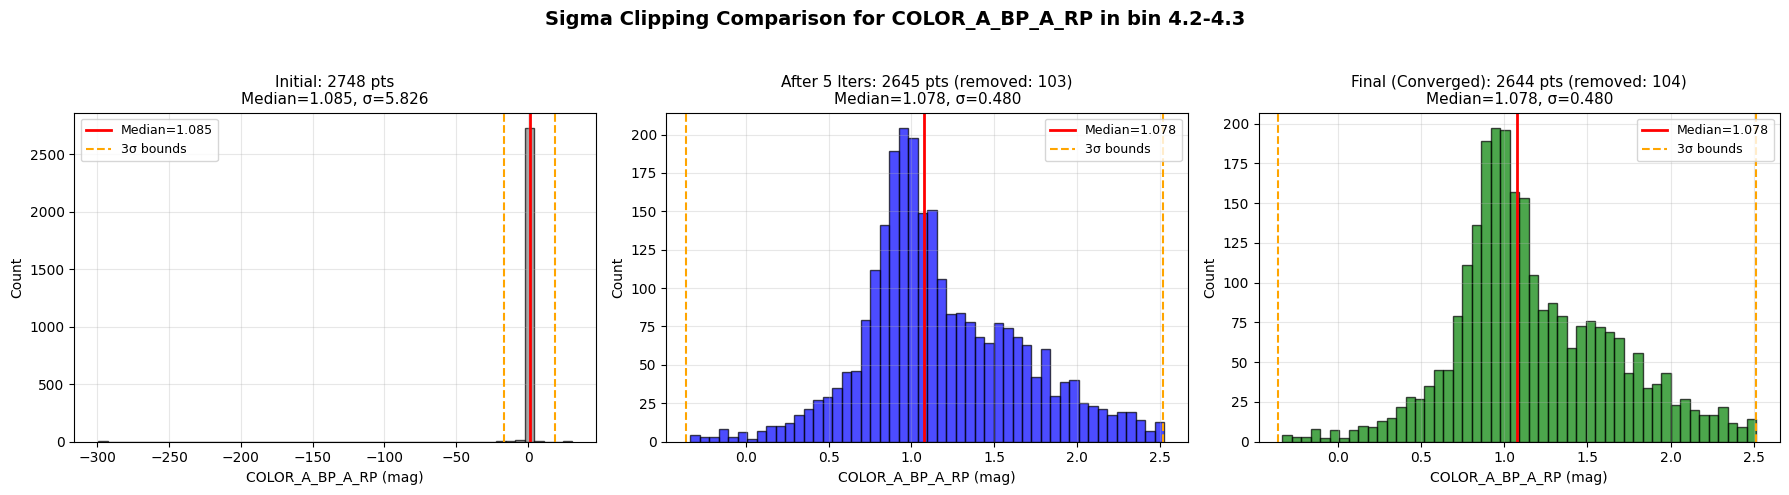


COLOR_A_BP_A_RP in 4.2-4.3:
  Initial:      2748 pts, median=1.0847, std=5.8260
  After 5 its:  2645 pts, median=1.0780, std=0.4802, removed=103
  Final:        2644 pts, median=1.0779, std=0.4796, removed=104
  Difference (5 iters vs converged): 1 additional pts removed


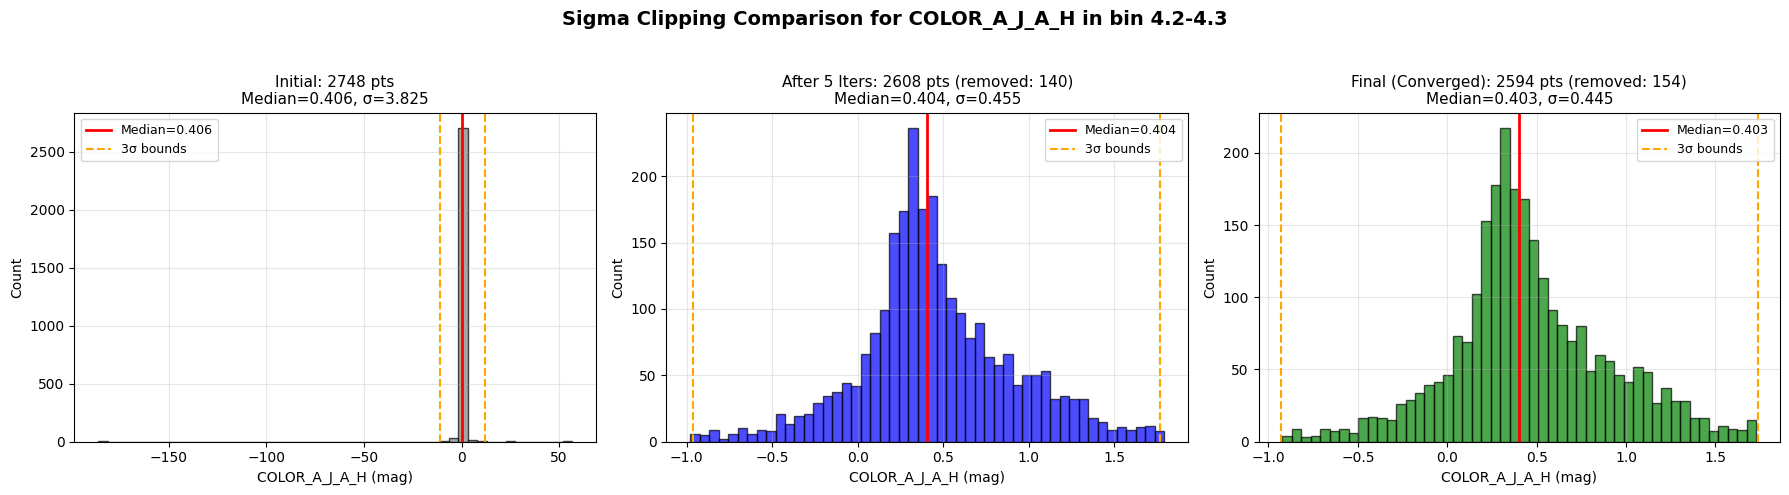


COLOR_A_J_A_H in 4.2-4.3:
  Initial:      2748 pts, median=0.4059, std=3.8253
  After 5 its:  2608 pts, median=0.4041, std=0.4548, removed=140
  Final:        2594 pts, median=0.4034, std=0.4450, removed=154
  Difference (5 iters vs converged): 14 additional pts removed


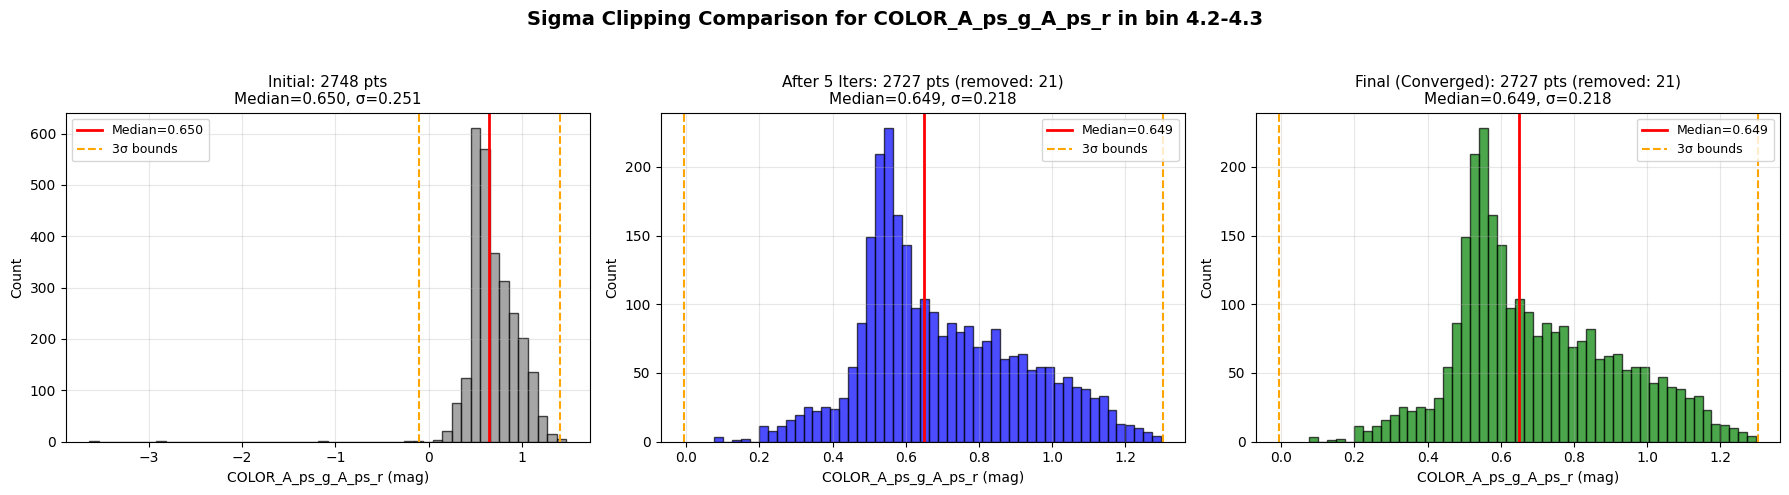


COLOR_A_ps_g_A_ps_r in 4.2-4.3:
  Initial:      2748 pts, median=0.6502, std=0.2511
  After 5 its:  2727 pts, median=0.6486, std=0.2179, removed=21
  Final:        2727 pts, median=0.6486, std=0.2179, removed=21
  Difference (5 iters vs converged): 0 additional pts removed


In [12]:
# Comparison visualization: Initial vs 5 iterations vs Final (converged)
def compare_clipping_iterations(df, color_name, bin_name):
    """
    Compare the effect of sigma clipping at different iteration stages.
    Shows: (1) Initial, (2) After 5 iterations, (3) Final converged result.
    """
    df_bin = df[df['logg_bin'] == bin_name]
    values = df_bin[color_name].dropna()
    
    if len(values) < 10:
        print(f"Not enough data points in bin {bin_name} for {color_name}")
        return
    
    # 1. Initial (no clipping)
    initial_median = np.median(values)
    initial_std = np.std(values)
    
    # 2. After 5 iterations
    clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, cenfunc='median', stdfunc='std')
    values_5 = values[~clipped_5.mask]
    median_5 = np.median(values_5)
    std_5 = np.std(values_5)
    
    # 3. Final (None iterations = until convergence)
    clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, cenfunc='median', stdfunc='std')
    values_final = values[~clipped_final.mask]
    median_final = np.median(values_final)
    std_final = np.std(values_final)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Initial
    ax1 = axes[0]
    ax1.hist(values, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax1.axvline(initial_median, color='red', linewidth=2, label=f'Median={initial_median:.3f}')
    ax1.axvline(initial_median - 3*initial_std, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax1.axvline(initial_median + 3*initial_std, color='orange', linestyle='--', linewidth=1.5)
    ax1.set_title(f'Initial: {len(values)} pts\nMedian={initial_median:.3f}, σ={initial_std:.3f}', fontsize=11)
    ax1.set_xlabel(f'{color_name} (mag)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: After 5 iterations
    ax2 = axes[1]
    ax2.hist(values_5, bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(median_5, color='red', linewidth=2, label=f'Median={median_5:.3f}')
    ax2.axvline(median_5 - 3*std_5, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax2.axvline(median_5 + 3*std_5, color='orange', linestyle='--', linewidth=1.5)
    removed_5 = len(values) - len(values_5)
    ax2.set_title(f'After 5 Iters: {len(values_5)} pts (removed: {removed_5})\nMedian={median_5:.3f}, σ={std_5:.3f}', fontsize=11)
    ax2.set_xlabel(f'{color_name} (mag)')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final (converged)
    ax3 = axes[2]
    ax3.hist(values_final, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax3.axvline(median_final, color='red', linewidth=2, label=f'Median={median_final:.3f}')
    ax3.axvline(median_final - 3*std_final, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax3.axvline(median_final + 3*std_final, color='orange', linestyle='--', linewidth=1.5)
    removed_final = len(values) - len(values_final)
    ax3.set_title(f'Final (Converged): {len(values_final)} pts (removed: {removed_final})\nMedian={median_final:.3f}, σ={std_final:.3f}', fontsize=11)
    ax3.set_xlabel(f'{color_name} (mag)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sigma Clipping Comparison for {color_name} in bin {bin_name}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clipping_comparison_{color_name}_{bin_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{color_name} in {bin_name}:")
    print(f"  Initial:     {len(values):5d} pts, median={initial_median:.4f}, std={initial_std:.4f}")
    print(f"  After 5 its: {len(values_5):5d} pts, median={median_5:.4f}, std={std_5:.4f}, removed={removed_5}")
    print(f"  Final:       {len(values_final):5d} pts, median={median_final:.4f}, std={std_final:.4f}, removed={removed_final}")
    print(f"  Difference (5 iters vs converged): {removed_final - removed_5} additional pts removed")

# Show comparison for representative colors and bins
print("=" * 80)
print("=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===")
print("=" * 80)

# Get middle bin for representative comparison
logg_bins_available = sorted(df['logg_bin'].dropna().unique())
middle_bin_idx = len(logg_bins_available) // 2
representative_bin = logg_bins_available[middle_bin_idx]

# Show comparisons for a few representative colors
representative_colors = ['COLOR_A_BP_A_RP', 'COLOR_A_J_A_H', 'COLOR_A_ps_g_A_ps_r']
for color in representative_colors:
    if color in color_combinations:
        compare_clipping_iterations(df, color, representative_bin)


In [13]:
# Summary table: Compare 5 iterations vs converged across ALL colors
print("\n" + "=" * 80)
print("=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===")
print("=" * 80)

summary_data = []
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    diff = total_removed_final - total_removed_5
    
    summary_data.append({
        'Color': color_name,
        'Total': total_original,
        'Removed (5 iters)': total_removed_5,
        'Removed (converged)': total_removed_final,
        'Extra removed': diff,
        '% Removed (5 iters)': f"{100*total_removed_5/total_original:.2f}%",
        '% Removed (converged)': f"{100*total_removed_final/total_original:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Overall summary
total_original_all = sum(s['Total'] for s in summary_data)
total_removed_5_all = sum(s['Removed (5 iters)'] for s in summary_data)
total_removed_final_all = sum(s['Removed (converged)'] for s in summary_data)

print(f"\n--- Overall (summed across all colors) ---")
print(f"Total data points (all colors combined): {total_original_all}")
print(f"Total removed after 5 iterations: {total_removed_5_all}")
print(f"Total removed after convergence: {total_removed_final_all}")
print(f"Additional removed by convergence: {total_removed_final_all - total_removed_5_all}")


=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===
              Color  Total  Removed (5 iters)  Removed (converged)  Extra removed % Removed (5 iters) % Removed (converged)
  COLOR_A_BAP_A_GSD 249253              12527                15529           3002               5.03%                 6.23%
 COLOR_A_BAP_A_ps_g 249253              10008                10977            969               4.02%                 4.40%
   COLOR_A_BAP_A_BP 249253              10559                11826           1267               4.24%                 4.74%
  COLOR_A_BAP_A_VAP 249253              10434                11721           1287               4.19%                 4.70%
 COLOR_A_BAP_A_ps_r 249253               9664                10509            845               3.88%                 4.22%
  COLOR_A_BAP_A_RSD 249253               9191                10036            845               3.69%                 4.03%
  COLOR_A_BAP_A_RAP 249253               8783                 9270  

## Phase 6: Save Filtered Dataset

Create clean dataset and save.

In [14]:
df_clean = df[~df['outlier_consensus']].copy()
df_outliers = df[df['outlier_consensus']].copy()

cols_to_drop = outlier_columns + ['logg_bin', 'outlier_consensus']
df_clean_out = df_clean.drop(columns=cols_to_drop, errors='ignore')

clean_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_K_dwarfs_logg_clean.csv'
df_clean_out.to_csv(clean_path, index=False)

print(f"Clean dataset saved: {len(df_clean_out)} stars -> {clean_path}")


Clean dataset saved: 160604 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_K_dwarfs_logg_clean.csv


## Phase 7: Sanity Check For Cleaned Dataset

Using the cleaned dataset (after outlier removal), generate comprehensive visualization for:
1. Color distributions plots (ALL colors)
2. ALL color vs logg plots without outliers
3. Bin-wise plots for ALL colors (detailed distributions per logg bin)

In [15]:
# Load the cleaned dataset for comprehensive visualization
clean_data_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_K_dwarfs_logg_clean.csv'

df_clean_viz = pd.read_csv(clean_data_path)

print(f"Cleaned dataset loaded for viz: {len(df_clean_viz)} stars")
for color_name, (mag1, mag2) in color_combinations.items():
    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]

# Apply the same logg bins (using edges calculated in Phase 3)
df_clean_viz['logg_bin'] = pd.cut(
    df_clean_viz['logg'], logg_bins, right=False,
    labels=[f'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}' for i in range(len(logg_bins)-1)]
)


Cleaned dataset loaded for viz: 160604 stars


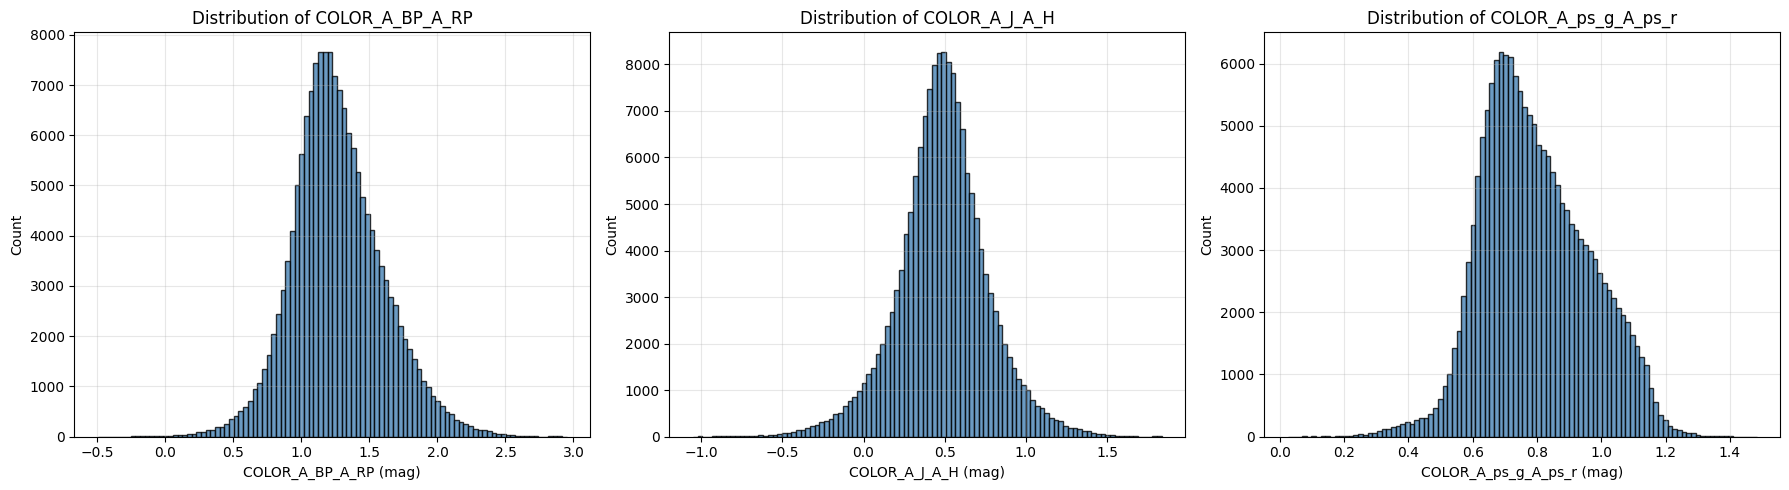

In [16]:
# 1. Color distribution plots for ALL colors (6x3 grid for 17 colors)
n_colors = len(representative_colors)
n_cols = 3
n_rows = (n_colors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    df_clean_viz[color_name].plot.hist(bins=100, ax=ax, alpha=0.8, color='steelblue', edgecolor='black')
    ax.set_xlabel(f'{color_name} (mag)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {color_name}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_color_distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()

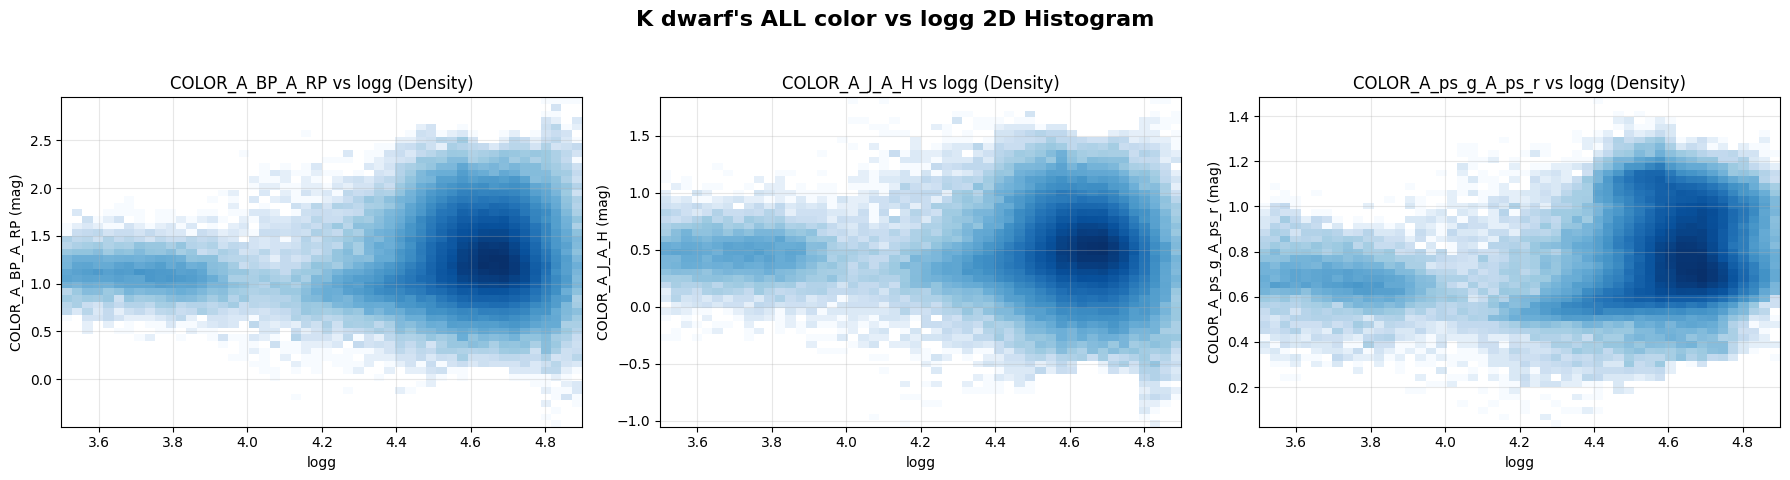

In [17]:
from matplotlib.colors import LogNorm

# 2. ALL color vs logg plots (2D Histograms)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    # Use 2D histogram with log scale to show density
    h = ax.hist2d(df_clean_viz['logg'], df_clean_viz[color_name], 
                  bins=50, cmap='Blues', norm=LogNorm(), cmin=1)
    
    ax.set_xlabel('logg')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs logg (Density)')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("K dwarf's ALL color vs logg 2D Histogram", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_logg_density.png', dpi=150, bbox_inches='tight')
plt.show()


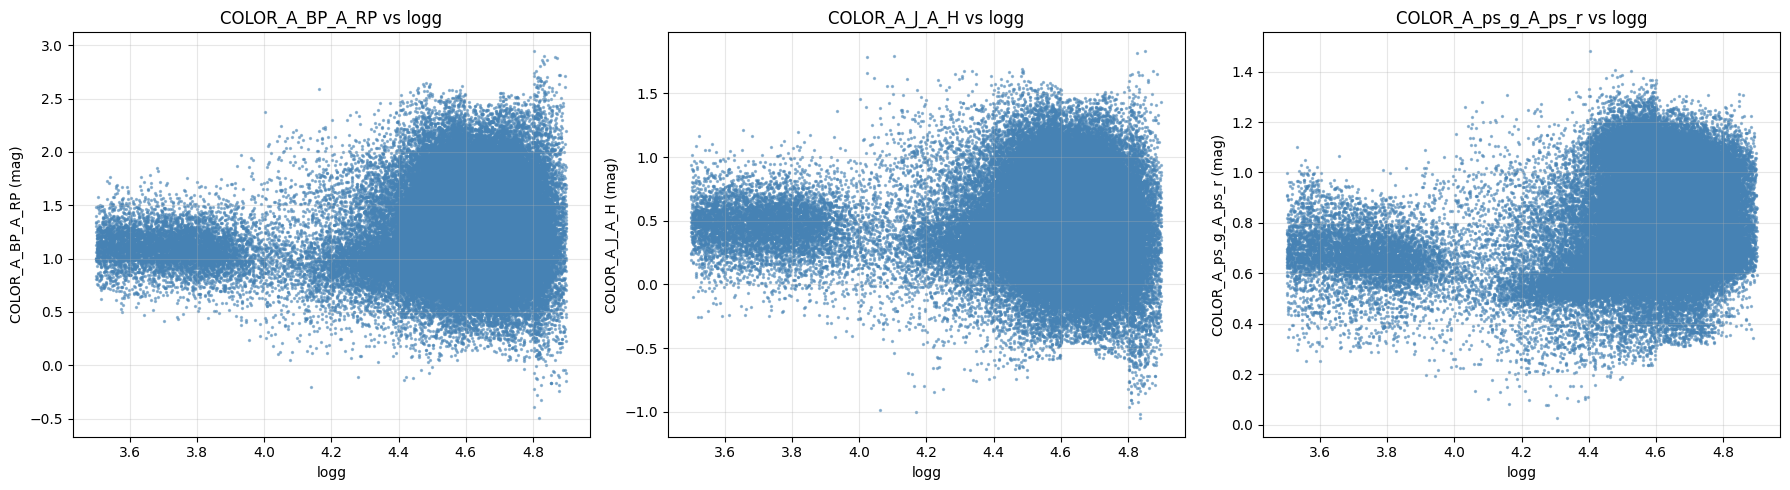

In [18]:
# 2. ALL color vs logg plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    ax.scatter(df_clean_viz['logg'], df_clean_viz[color_name], color='steelblue', alpha=0.5, s=2)
    ax.set_xlabel('logg')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs logg')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_logg.png', dpi=150, bbox_inches='tight')
plt.show()
